# 04 Baseline Models

## Purpose

This notebook trains and evaluates traditional machine learning models using the extracted acoustic features.

The objectives are:

1. Load the extracted feature dataset.
2. Prepare training and testing data.
3. Train baseline machine learning models.
4. Compare model performance.
5. Establish a benchmark before implementing deep learning models.

Models:

- Random Forest
- Support Vector Machine (SVM)

Evaluation Metrics:

- Accuracy
- Precision
- Recall
- F1-Score
- Confusion Matrix

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.ensemble import RandomForestClassifier

from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries loaded successfully")

Libraries loaded successfully


## Load Feature Dataset

In [2]:
FEATURE_PATH = (
    Path("../data/features")
    / "urban_sound_features.csv"
)

features_df = pd.read_csv(FEATURE_PATH)

print(features_df.shape)

features_df.head()

(8732, 41)


,mfcc_0,mfcc_1,mfcc_2,mfcc_3,mfcc_4,mfcc_5,mfcc_6,mfcc_7,mfcc_8,mfcc_9,...,mfcc_31,mfcc_32,mfcc_33,mfcc_34,mfcc_35,mfcc_36,mfcc_37,mfcc_38,mfcc_39,label
0,-211.93698,62.581207,-122.813150,-60.745293,-13.893760,-29.789835,-3.978875,11.682742,12.963828,8.336421,...,7.510886,-0.885360,2.393814,-6.392372,-2.131859,2.276015,-0.791084,-1.540068,1.321150,dog_bark
1,-417.00520,99.336624,-42.995586,51.073326,9.853778,7.969693,11.197088,1.929117,7.030397,4.270228,...,2.277220,-1.539243,0.767109,-0.878724,0.908738,-2.681854,1.706798,-1.793606,1.761385,children_playing
2,-452.39316,112.362530,-37.578068,43.195866,8.631845,15.379366,16.882149,1.233047,6.833122,3.900116,...,-0.154540,-5.285954,-0.790016,-2.979211,-0.202845,-3.088082,3.808014,-0.090056,0.869102,children_playing
3,-406.47922,91.196600,-25.043558,42.784520,11.586844,5.054164,12.431632,-1.599949,6.656064,1.442355,...,1.279155,0.635733,1.414131,-2.831120,1.808179,-2.178431,-0.436480,-3.051344,-0.170013,children_playing
4,-439.63873,103.862230,-42.658787,50.690277,12.209422,15.873466,11.729268,1.533585,11.292244,2.548622,...,-0.774089,-0.985246,2.566369,-2.976879,1.071741,-1.825602,3.291397,-0.169670,1.392584,children_playing


## Prepare Features and Labels

In [3]:
X = features_df.drop(
    columns=["label"]
)

y = features_df["label"]

print(X.shape)
print(y.shape)

(8732, 40)
(8732,)


## Encode Labels

In [4]:
label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print(label_encoder.classes_)

['air_conditioner' 'car_horn' 'children_playing' 'dog_bark' 'drilling'
 'engine_idling' 'gun_shot' 'jackhammer' 'siren' 'street_music']


## Train-Test Split

80% Training

20% Testing

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print(X_train.shape)
print(X_test.shape)

(6985, 40)
(1747, 40)


# Random Forest Model

In [6]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train,
    y_train
)

print("Random Forest Training Complete")

Random Forest Training Complete


In [7]:
rf_predictions = rf_model.predict(
    X_test
)

rf_accuracy = accuracy_score(
    y_test,
    rf_predictions
)

rf_precision = precision_score(
    y_test,
    rf_predictions,
    average="weighted"
)

rf_recall = recall_score(
    y_test,
    rf_predictions,
    average="weighted"
)

rf_f1 = f1_score(
    y_test,
    rf_predictions,
    average="weighted"
)

print("Accuracy :", rf_accuracy)
print("Precision:", rf_precision)
print("Recall   :", rf_recall)
print("F1 Score :", rf_f1)

Accuracy : 0.8780767029192902
Precision: 0.8822007265172568
Recall   : 0.8780767029192902
F1 Score : 0.8773917903775763


In [8]:
print(
    classification_report(
        y_test,
        rf_predictions,
        target_names=label_encoder.classes_
    )
)

                  precision    recall  f1-score   support

 air_conditioner       0.97      0.95      0.96       200
        car_horn       0.97      0.79      0.87        86
children_playing       0.77      0.87      0.82       200
        dog_bark       0.82      0.76      0.79       200
        drilling       0.91      0.86      0.88       200
   engine_idling       0.95      0.96      0.95       200
        gun_shot       0.94      0.63      0.75        75
      jackhammer       0.89      0.94      0.91       200
           siren       0.91      0.94      0.92       186
    street_music       0.79      0.88      0.83       200

        accuracy                           0.88      1747
       macro avg       0.89      0.86      0.87      1747
    weighted avg       0.88      0.88      0.88      1747



## Random Forest Confusion Matrix

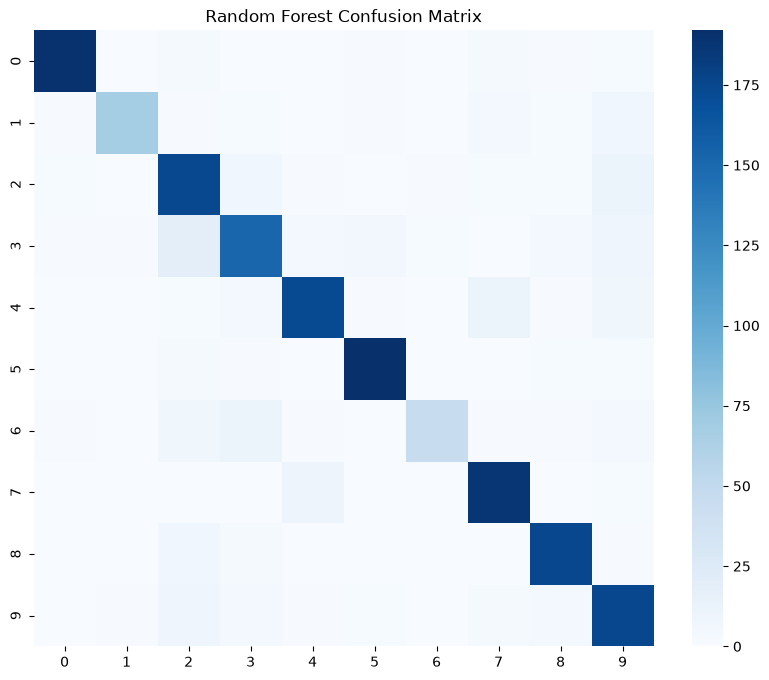

In [9]:
cm = confusion_matrix(
    y_test,
    rf_predictions
)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=False,
    cmap="Blues"
)

plt.title(
    "Random Forest Confusion Matrix"
)

plt.show()

# Support Vector Machine

In [10]:
svm_model = SVC(
    kernel="rbf"
)

svm_model.fit(
    X_train,
    y_train
)

print("SVM Training Complete")

SVM Training Complete


In [11]:
svm_predictions = svm_model.predict(
    X_test
)

svm_accuracy = accuracy_score(
    y_test,
    svm_predictions
)

svm_precision = precision_score(
    y_test,
    svm_predictions,
    average="weighted"
)

svm_recall = recall_score(
    y_test,
    svm_predictions,
    average="weighted"
)

svm_f1 = f1_score(
    y_test,
    svm_predictions,
    average="weighted"
)

print("Accuracy :", svm_accuracy)
print("Precision:", svm_precision)
print("Recall   :", svm_recall)
print("F1 Score :", svm_f1)

Accuracy : 0.6061820263308529
Precision: 0.6354249300478487
Recall   : 0.6061820263308529
F1 Score : 0.6047864514134877


In [12]:
print(
    classification_report(
        y_test,
        svm_predictions,
        target_names=label_encoder.classes_
    )
)

                  precision    recall  f1-score   support

 air_conditioner       0.56      0.64      0.60       200
        car_horn       0.98      0.52      0.68        86
children_playing       0.53      0.60      0.56       200
        dog_bark       0.64      0.61      0.63       200
        drilling       0.60      0.54      0.57       200
   engine_idling       0.70      0.55      0.62       200
        gun_shot       0.89      0.23      0.36        75
      jackhammer       0.55      0.74      0.64       200
           siren       0.82      0.80      0.81       186
    street_music       0.45      0.56      0.49       200

        accuracy                           0.61      1747
       macro avg       0.67      0.58      0.60      1747
    weighted avg       0.64      0.61      0.60      1747



## SVM Confusion Matrix

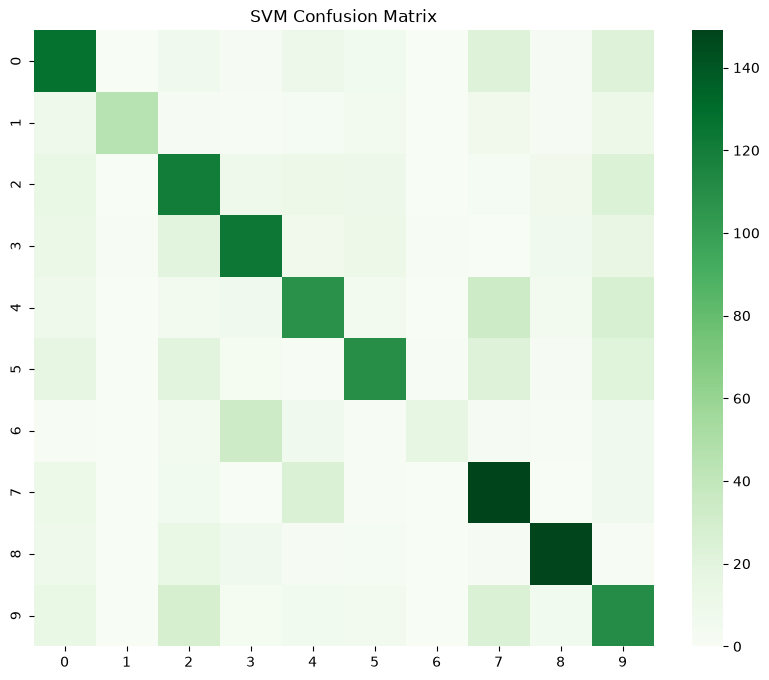

In [13]:
cm = confusion_matrix(
    y_test,
    svm_predictions
)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=False,
    cmap="Greens"
)

plt.title(
    "SVM Confusion Matrix"
)

plt.show()

## Model Comparison

In [14]:
comparison_df = pd.DataFrame({
    "Model": [
        "Random Forest",
        "SVM"
    ],
    "Accuracy": [
        rf_accuracy,
        svm_accuracy
    ],
    "Precision": [
        rf_precision,
        svm_precision
    ],
    "Recall": [
        rf_recall,
        svm_recall
    ],
    "F1 Score": [
        rf_f1,
        svm_f1
    ]
})

comparison_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Random Forest,0.878077,0.882201,0.878077,0.877392
1,SVM,0.606182,0.635425,0.606182,0.604786


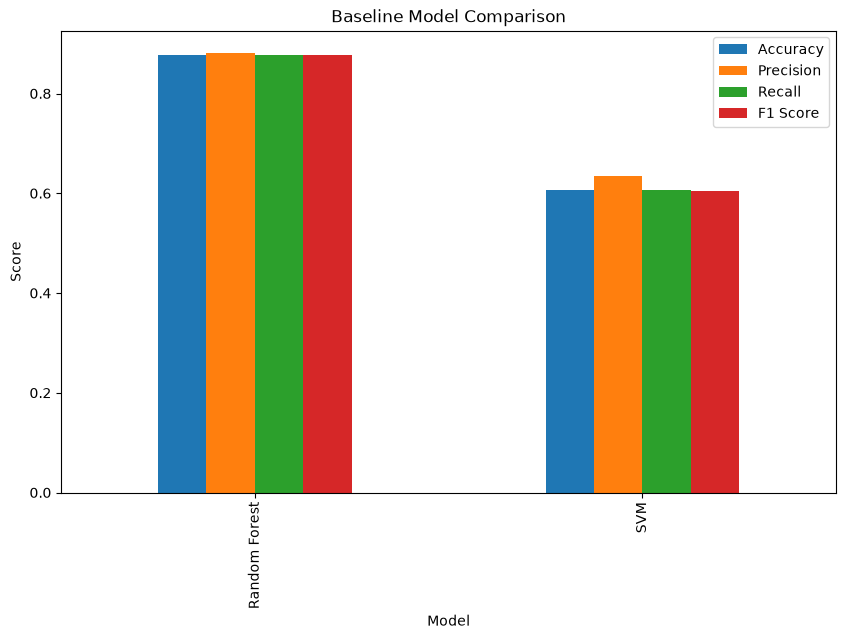

In [15]:
comparison_df.set_index(
    "Model"
).plot(
    kind="bar",
    figsize=(10,6)
)

plt.title(
    "Baseline Model Comparison"
)

plt.ylabel(
    "Score"
)

plt.show()

## Save Best Model

The best-performing model will be saved for later comparison with the CNN model.

In [16]:
import joblib

MODEL_DIR = Path(
    "../saved_models"
)

MODEL_DIR.mkdir(
    exist_ok=True
)

joblib.dump(
    rf_model,
    MODEL_DIR /
    "random_forest_baseline.pkl"
)

print("Model saved")

Model saved


### Completed baseline models